# Projeto de Fundamentos de Aprendizagem Automática 2025/26 - Etapa 1
### Trabalho em grupo



## Problema Classificativo

> **Objetivo:** Prever o nível de exaustão tendo em conta as atividades fora da faculdade.

### Escala de Exaustão

| Nível        | Intervalo |
|--------------|-----------|
| Very Low     | 0 – 20    |
| Low          | 20 – 40   |
| Medium       | 40 – 60   |
| High         | 60 – 80   |
| Very High    | 80 – 100  |

## Problema Regressivo ##


> **Objetivo:**  Prever a nota final de um estudante com base apenas nos seus hábitos de estudo e saúde.

## Stakeholders

**Problema de Classificação (Burnout):** Serviços de apoio psicológico e gabinetes de bem-estar das universidades, estes poderiam usar o modelo para identificar estudantes em risco de exaustão extrema e intervir preventivamente, antes de o problema se agravar.

**Problema de Regressão (Exam Score):** Gabinetes de tutoria e orientação académica, estes poderiam sinalizar estudantes com previsão de notas baixas para programas de reforço ou acompanhamento personalizado. Os próprios estudantes também beneficiariam, ao perceberem quais hábitos têm maior impacto no seu desempenho.

In [1]:
from sklearn.model_selection import train_test_split, StratifiedKFold, KFold, cross_validate, GridSearchCV
from sklearn.tree import DecisionTreeClassifier, DecisionTreeRegressor
from sklearn.linear_model import LinearRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import (
    accuracy_score, f1_score, classification_report,
    confusion_matrix, ConfusionMatrixDisplay,
    mean_absolute_error, root_mean_squared_error, r2_score
)
from sklearn.preprocessing import StandardScaler, RobustScaler, MinMaxScaler
from sklearn.preprocessing import OneHotEncoder, OrdinalEncoder
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt


# 1. Pre-processamento dos dados


## 1.1 Load nos dados
Load nas Colunas das features e targets.


In [2]:
def load_data(file_csv):
    df = pd.read_csv(file_csv)
    nc = df.shape[1]
    
    df_X = df.iloc[:, 1:nc-4]
    df_y = df.iloc[:, nc-4:]
    
    return df_X, df_y

## 1.2 Observação da Distribuição Estatística das Variáveis Numéricas

Geração de gráficos para analisar a distribuição estatística das variáveis numéricas, com o objetivo de:

- Compreender a forma da distribuição dos dados  
- Identificar possíveis *outliers*  
- Determinar o tipo de *scaling* mais adequado (**StandardScaler**, **MinMaxScaler**, **RobustScaler**)  
- Escolher o método apropriado para tratar *missing values* (**mediana**, **média**, **moda**, etc.)

['age', 'gender', 'academic_level', 'study_hours', 'self_study_hours', 'online_classes_hours', 'social_media_hours', 'gaming_hours', 'sleep_hours', 'screen_time_hours', 'exercise_minutes', 'caffeine_intake_mg', 'part_time_job', 'upcoming_deadline', 'internet_quality', 'mental_health_score']


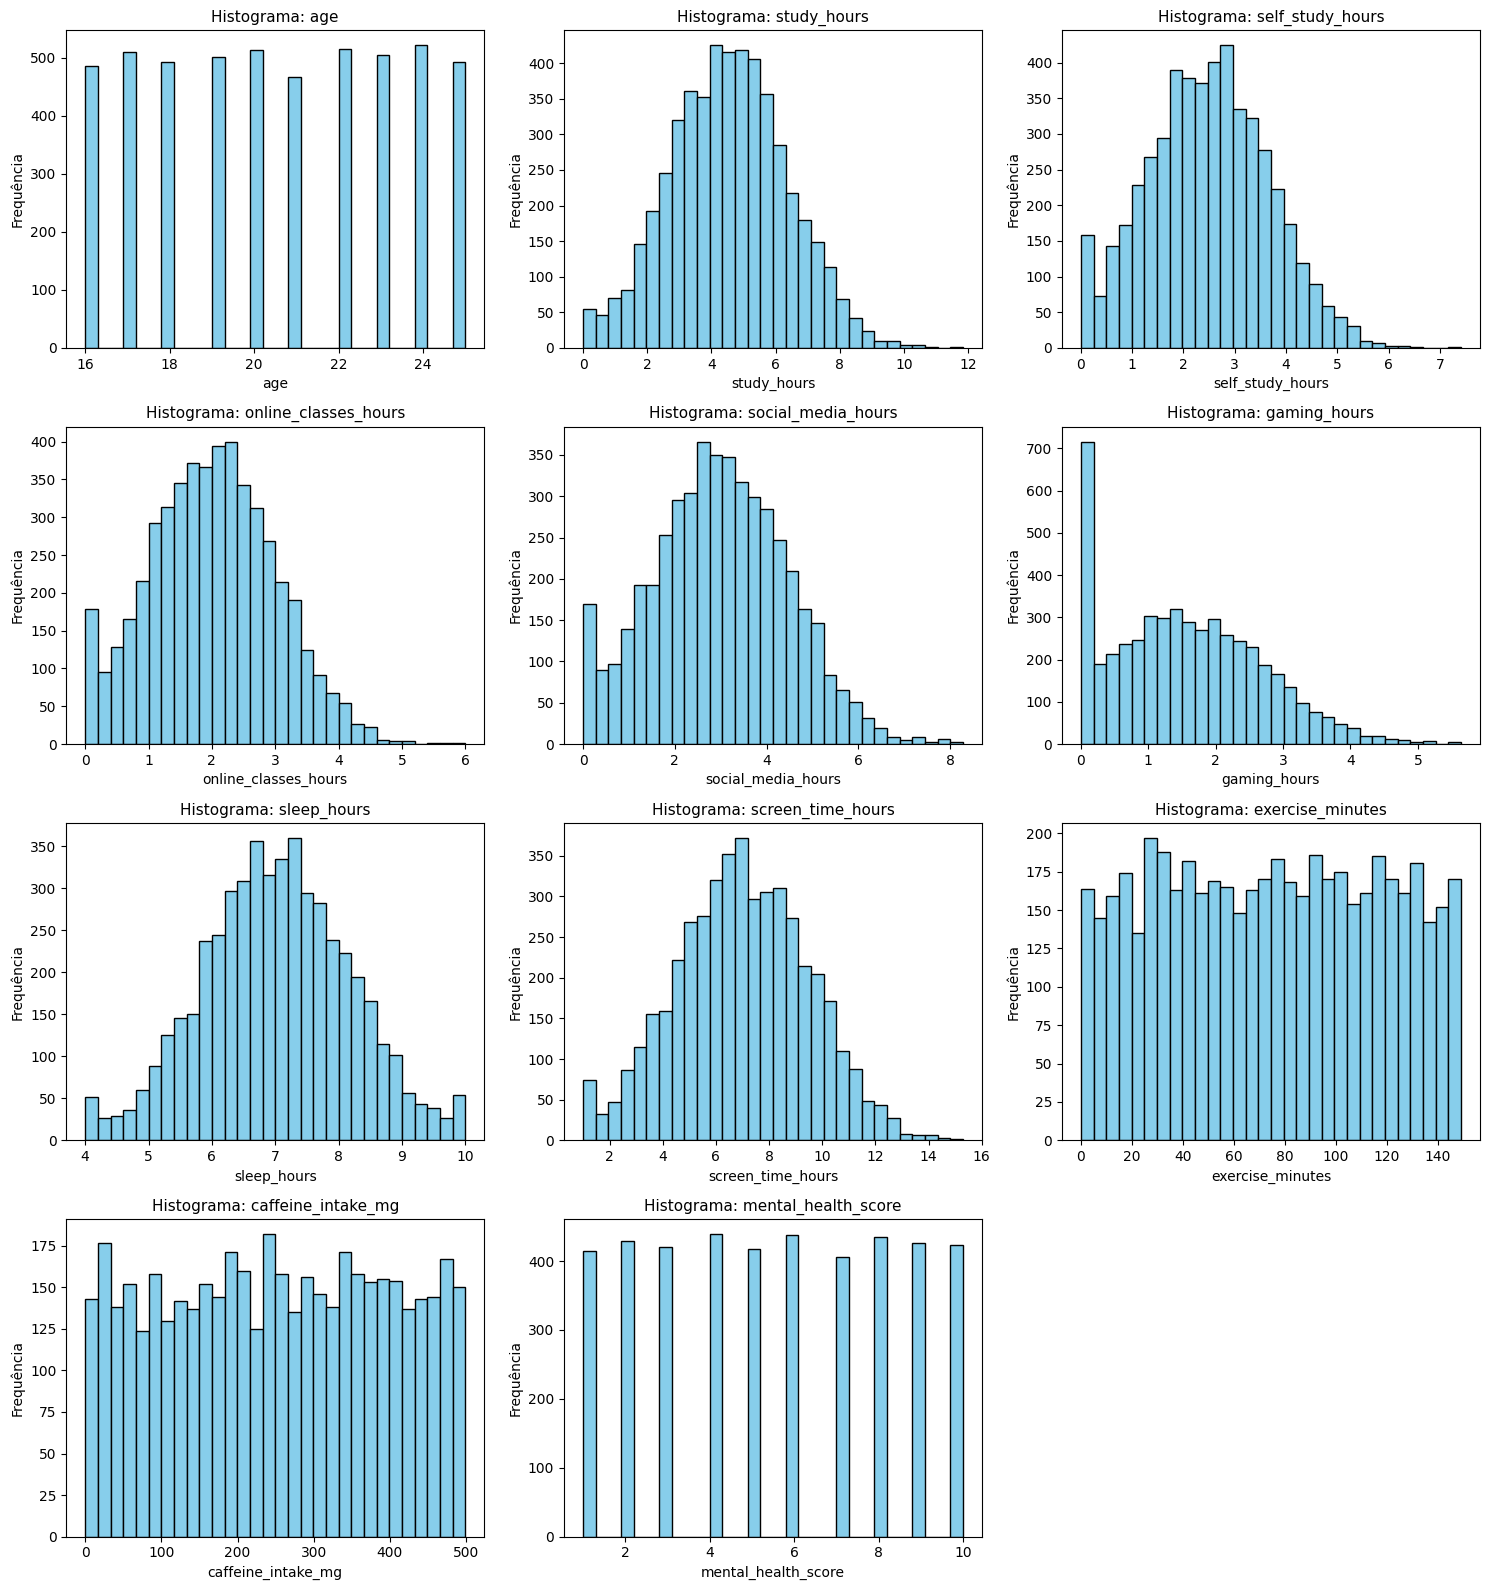

In [3]:

df_X, df_y = load_data("Dados_Projeto/student_records_missing.csv")

numerical_features = [ "age",
    "study_hours", "self_study_hours", "online_classes_hours",
    "social_media_hours", "gaming_hours", "sleep_hours",
    "screen_time_hours", "exercise_minutes", "caffeine_intake_mg",
    "mental_health_score"
]

print(list(df_X.columns))
numerical_X = df_X[numerical_features]

n_cols = 3
n_rows = (len(numerical_features) + n_cols - 1) // n_cols

plt.figure(figsize=(5 * n_cols, 4 * n_rows))

for i, col in enumerate(numerical_features, 1):
    plt.subplot(n_rows, n_cols, i)

    plt.hist(
        numerical_X[col],
        bins=30,
        color='skyblue',
        edgecolor='black',
        density=False
    )

    plt.title(f'Histograma: {col}', fontsize=11)
    plt.xlabel(col)
    plt.ylabel('Frequência')

plt.tight_layout()
plt.show()

## 1.3 Identificação e Tratamento dos missings values

### Identificação dos Missing Values
Antes de decidir o método de imputação, verificamos quais colunas têm valores em falta e quantos.

### Numerical Values
**Média**: Usámos a média para as features com distribuição aproximadamente simétrica, onde a média é representativa do centro dos dados e não distorce as propriedades da feature.

**Mediana**: Usamos para o "gaming_hours" devido à existência de outliers, onde a média seria distorcida pelos valores extremos.

**Moda**: Usamos no mental_health_score porque o intevalo destes é (1,10), ao usarmos a média ou mediana pode surgir valores não inteiros.


### Categorical Values

É recomendado que usamos sempre o valor mais comum, a **moda**.




In [4]:
# === Contagem de missing values ===
missing = df_X.isnull().sum()
missing_only = missing[missing > 0]

print("Colunas com valores em falta:\n")
for col, count in missing_only.items():
    pct = count / len(df_X) * 100
    print(f"  {col}: {count} ({pct:.1f}%)")

print(f"\nColunas sem valores em falta: {(missing == 0).sum()} de {len(missing)}")

Colunas com valores em falta:

  gender: 150 (3.0%)
  academic_level: 100 (2.0%)
  social_media_hours: 250 (5.0%)
  screen_time_hours: 400 (8.0%)
  caffeine_intake_mg: 500 (10.0%)
  mental_health_score: 750 (15.0%)

Colunas sem valores em falta: 10 de 16


In [5]:
mean_imputation_n = [
    "study_hours",
    "self_study_hours",
    "online_classes_hours",
    "social_media_hours",
    "sleep_hours",
    "screen_time_hours",
    "age",
    "exercise_minutes",
    "caffeine_intake_mg"
]

median_imputation_n = ["gaming_hours"]

mode_imputation_n = ["mental_health_score"]

mode_imputation_c = ["gender", "academic_level", "internet_quality", "upcoming_deadline", "part_time_job"]
    

## 1.4 Encoding os categorical values
Nos categorical values fazemos o enconding delas usando:

**One-Hot Enconding (OHE)**: usamos no "gender" pois é um valor que não tem hierarquia.

**Ordinal enconding**: usamos nas outras "academic_level" e "internet_quality" pois estas têm hierarquia, usando o Ordinal esta hierarquia não se perderá.

Nota: As colunas "upcoming_deadline" e "part_time_job" são valores binários (0,1) ou seja não é necessário o encoding destas

In [6]:
OHE_enconding = ["gender"]
Ordinal_encoding = ["academic_level", "internet_quality"]


## 1.5 Scaling dos numerical values

O processo final no pré-processamento dos dados é o fazer o scaling para isso usámos:

**StandardScaler**: Subtrai a média e divide pelo desvio padrão, colocando cada feature com média 0 e variância 1 (z = (x - μ) / σ). Torna features com escalas diferentes directamente comparáveis entre si. Não lida bem com outliers, por isso é usado nas features sem outliers significativos, que é o caso da maioria das nossas features.

**MinMaxScaler**: Escala os valores para o intervalo [0,1]. O mental_health_score tem um intervalo natural e bem definido (1-10) sem outliers significativos, o que o torna adequado para este scaler (outliers comprimiriam os restantes dados).

**RobustScaler**: Usado para tratar outliers, o caso do "gaming_hours", como visível pela cauda direita no histograma.

In [7]:
StandardScaler_list = [
    "study_hours",
    "self_study_hours",
    "online_classes_hours",
    "social_media_hours",
    "sleep_hours",
    "screen_time_hours",
    "age",
    "exercise_minutes",
    "caffeine_intake_mg"
]
RobustScaler_list = ["gaming_hours"]
MinMaxScaler_list = ["mental_health_score"]

## 1.6 Criação da pipeline
Juntar as pipelines da imputação, do encode e do scaling.

**Nota sobre a ordem imputação/scaling:** A matéria recomenda fazer scaling antes de imputação
para não alterar as propriedades das features com valores artificiais.
No entanto, reparamos que os scalers do scikit-learn (StandardScaler, MinMaxScaler, RobustScaler)
não aceitam valores em falta (NaN), o que obriga a imputar primeiro.

In [8]:
full_pipeline = ColumnTransformer(
    transformers=[

        # Mean imputation + StandardScaler
        ("standard", Pipeline([
            ("imputer", SimpleImputer(strategy="mean")),
            ("scaler",  StandardScaler()),
        ]), mean_imputation_n),

        # Median imputation + RobustScaler
        ("robust", Pipeline([
            ("imputer", SimpleImputer(strategy="median")),
            ("scaler",  RobustScaler()),
        ]), median_imputation_n),

        # Mode imputation + MinMaxScaler (numérica)
        ("minmax", Pipeline([
            ("imputer", SimpleImputer(strategy="most_frequent")),
            ("scaler",  MinMaxScaler()),
        ]), mode_imputation_n),

        # Mode imputation + OHE (gender)
        ("ohe", Pipeline([
            ("imputer", SimpleImputer(strategy="most_frequent")),
            ("encoder", OneHotEncoder(handle_unknown="ignore")),
        ]), OHE_enconding),

        # Mode imputation + OrdinalEncoder (academic_level, internet_quality)
        ("ordinal", Pipeline([
            ("imputer", SimpleImputer(strategy="most_frequent")),
            ("encoder", OrdinalEncoder(categories=[
                ["High School", "Undergraduate", "Postgraduate"],
                ["Poor", "Average", "Good"]
            ])),
        ]), Ordinal_encoding),

        # Mode imputation apenas (binárias: upcoming_deadline, part_time_job)
        ("binary", Pipeline([
            ("imputer", SimpleImputer(strategy="most_frequent")),
        ]), ["upcoming_deadline", "part_time_job"]),

    ],
    remainder="passthrough"  # passa as colunas restantes (ex: student_id) sem alteração
)

# 2. Treino e Avaliação de Modelos Base

## 2.1 Definição das targets

### Classificação
Para o problema de classificação, convertemos o `burnout_level` (contínuo, 0-100) em 5 classes discretas:
- Very-Low (0-20), Low (20-40), Medium (40-60), High (60-80), Very-High (80-100)

### Regressão
Para o problema de regressão, usamos o `exam_score` diretamente como variável contínua.

In [9]:
# Load dos dados
df_X, df_y = load_data("Dados_Projeto/student_records_missing.csv")

# Target de Regressão: exam_score (contínuo)
y_reg = df_y["exam_score"]

# Target de Classificação: burnout_level → 5 classes
bins = [0, 20, 40, 60, 80, 100]
labels = ["Very-Low", "Low", "Medium", "High", "Very-High"]
y_clf = pd.cut(df_y["burnout_level"], bins=bins, labels=labels, include_lowest=True)

# Verificar a distribuição das classes
print("Distribuição das classes de burnout:")
print(y_clf.value_counts().sort_index())
print(f"\nTotal: {len(y_clf)}")

Distribuição das classes de burnout:
burnout_level
Very-Low      174
Low          1625
Medium       2386
High          778
Very-High      37
Name: count, dtype: int64

Total: 5000


## 2.2 Divisão dos dados (Train / Test)

Separamos 80% para aprendizagem (learning set) e 20% para teste final.
- Na classificação usamos `stratify` para manter as proporções das classes em ambos os conjuntos.
- O `random_state=42` garante a reprodutibilidade.

**Importante:** Os dados ficam em bruto (sem pré-processamento) após a partição.
A imputação e o scaling são aplicados **dentro de cada fold** do cross-validation (via Pipeline),
garantindo que os parâmetros do imputer são calculados apenas nos dados de treino de cada fold,
sem data leakage para os dados de validação ou de teste.

In [10]:
# Split ANTES do pré-processamento (dados crus)
# O pré-processamento ocorre dentro de cada fold do CV e na avaliação final,
# evitando data leakage dos parâmetros de imputação.

# Split para CLASSIFICAÇÃO
X_train_clf, X_test_clf, y_train_clf, y_test_clf = train_test_split(
    df_X, y_clf, test_size=0.2, random_state=42, stratify=y_clf
)

# Split para REGRESSÃO
X_train_reg, X_test_reg, y_train_reg, y_test_reg = train_test_split(
    df_X, y_reg, test_size=0.2, random_state=42
)

print(f"Classificação — Train: {X_train_clf.shape}, Test: {X_test_clf.shape}")
print(f"Regressão    — Train: {X_train_reg.shape}, Test: {X_test_reg.shape}")


Classificação — Train: (4000, 16), Test: (1000, 16)
Regressão    — Train: (4000, 16), Test: (1000, 16)


## 2.3 Métricas de Avaliação

As métricas são definidas em dois níveis:
- **Primária (gold standard):** usada para comparar modelos na avaliação final e como critério de otimização no Grid Search.
- **Secundária:** reportada adicionalmente para dar contexto, mas não determina a seleção de modelos.

### Classificação (Burnout Level)
- **Primária (gold standard): F1-Score (macro)**
  O dataset é desbalanceado ("Very-High" ~0.7%, "Medium" ~48%). Accuracy seria enganadora: um modelo que previsse sempre "Medium" teria ~48% mas seria inútil para os serviços de apoio psicológico, que precisam de detetar casos extremos. O F1-macro dá peso igual a todas as classes, penalizando modelos que ignorem as minoritárias — alinhado com o objetivo de identificar estudantes em risco.

- **Secundária: Accuracy** — Referência geral da taxa de acertos, analisada sempre em conjunto com o F1-macro.

### Regressão (Exam Score)
- **Primária (gold standard): R²**
  Mede a proporção de variância do exam_score explicada pelo modelo. É independente de escala e permite comparar diretamente modelos distintos. R²=1 é perfeito; R²=0 significa que o modelo não é melhor do que prever a média — relevante para os gabinetes de tutoria avaliarem a utilidade prática.

- **Secundária: MAE** — Erro médio absoluto em pontos do exam_score. Robusto a outliers e interpretável diretamente na escala da nota (ex: "o modelo erra em média 5 pontos").

Nota: Usamos as mesmas métricas para todos os modelos dentro de cada tarefa
para permitir a comparação direta entre eles.

## 2.4 Modelos Baseline — Classificação (Burnout Level)

Usamos dois modelos interpretáveis como baseline:
1. **Árvore de Decisão (Decision Tree)**: Modelo lógico, altamente interpretável — permite visualizar as regras de decisão.
2. **KNN (K-Nearest Neighbors)**: Modelo geométrico, baseia-se na proximidade entre exemplos no espaço das features.

Ambos são avaliados com **Stratified 5-Fold Cross-Validation** sobre o learning set,
como exigido nos requisitos obrigatórios do projeto.

In [11]:
# === Cross-Validation para Classificação ===
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# Modelos baseline de classificação
clf_model_definitions = {
    "Decision Tree": DecisionTreeClassifier(random_state=42),
    "KNN (k=5)": KNeighborsClassifier(n_neighbors=5),
}

clf_cv_results = []

for name, model in clf_model_definitions.items():
    # Pipeline completa: pré-processamento + modelo
    # Em cada fold, o imputer é ajustado APENAS nos dados de treino desse fold,
    # sem ver os dados de validação → sem data leakage
    pipe = Pipeline([
        ("prep", full_pipeline),
        ("clf",  model),
    ])

    scores = cross_validate(
        pipe, X_train_clf, y_train_clf, cv=skf,
        scoring=["accuracy", "f1_macro"],
        return_train_score=True
    )

    clf_cv_results.append({
        "Model": name,
        "Mean Train Accuracy": scores["train_accuracy"].mean(),
        "Mean Val Accuracy": scores["test_accuracy"].mean(),
        "Std Val Accuracy": scores["test_accuracy"].std(),
        "Mean Train F1-macro": scores["train_f1_macro"].mean(),
        "Mean Val F1-macro": scores["test_f1_macro"].mean(),
        "Std Val F1-macro": scores["test_f1_macro"].std(),
    })

clf_cv_df = pd.DataFrame(clf_cv_results).round(4)
clf_cv_df


,Model,Mean Train Accuracy,Mean Val Accuracy,Std Val Accuracy,Mean Train F1-macro,Mean Val F1-macro,Std Val F1-macro
0,Decision Tree,1.0000,0.6283,0.009,1.0000,0.4831,0.0309
1,KNN (k=5),0.7086,0.5562,0.011,0.4742,0.3236,0.0135


Com estes valores percebemos que:

**Decision Tree** Que existe grande overfitting, e é necessário um corte na profundidade da árvore.

**KNN (k=5)** Menos overfitting mas tem problemas com valores mais baixos.

## 2.4.1 Grid Search — Classificação

Para encontrar os melhores hiperparâmetros de cada modelo, usamos **GridSearchCV** com a mesma estratégia de Stratified 5-Fold.

A métrica de otimização é o **F1-macro** (métrica primária / gold standard), pois é o que queremos maximizar dado o desequilíbrio de classes.

O `refit=True` (default) faz com que o GridSearchCV re-treine o melhor modelo em todo o X_train antes de disponibilizar o `best_estimator_`, pronto para avaliação no test set.

In [12]:
# === Grid Search — Classificação ===
# Cada pipeline inclui pré-processamento + modelo, logo o imputer é ajustado
# apenas nos folds de treino do CV interno do GridSearchCV.

param_grid_dt_clf = {
    "clf__max_depth":        [3, 5, 7, 10, None],
    "clf__min_samples_split": [2, 5, 10],
    "clf__criterion":        ["gini", "entropy"],
}

param_grid_knn = {
    "clf__n_neighbors": [3, 5, 7, 9, 11],
    "clf__weights":     ["uniform", "distance"],
}

gs_clf_configs = [
    ("Decision Tree", DecisionTreeClassifier(random_state=42), param_grid_dt_clf),
    ("KNN",           KNeighborsClassifier(),                   param_grid_knn),
]

gs_clf_results = {}

for name, model, param_grid in gs_clf_configs:
    pipe = Pipeline([("prep", full_pipeline), ("clf", model)])
    gs = GridSearchCV(pipe, param_grid, scoring="f1_macro", cv=skf, n_jobs=-1, refit=True)
    gs.fit(X_train_clf, y_train_clf)
    gs_clf_results[name] = gs

    print(f"\n--- {name} ---")
    print(f"Melhores parâmetros : {gs.best_params_}")
    print(f"Melhor F1-macro (CV): {gs.best_score_:.4f}")



--- Decision Tree ---
Melhores parâmetros : {'clf__criterion': 'entropy', 'clf__max_depth': 10, 'clf__min_samples_split': 10}
Melhor F1-macro (CV): 0.5229

--- KNN ---
Melhores parâmetros : {'clf__n_neighbors': 3, 'clf__weights': 'distance'}
Melhor F1-macro (CV): 0.3474


## 2.5 Modelos Baseline — Regressão (Exam Score)

Usamos dois modelos interpretáveis como baseline:
1. **Regressão Linear**: O modelo de regressão mais clássico — cada coeficiente indica diretamente o impacto de uma feature no exam_score.
2. **Árvore de Decisão (Regressão)**: Segmenta os dados em regiões e prevê a média dos valores nessa região.

Ambos avaliados com **5-Fold Cross-Validation**.

In [13]:
# === Cross-Validation para Regressão ===
kf = KFold(n_splits=5, shuffle=True, random_state=42)

# Modelos baseline de regressão
reg_model_definitions = {
    "Linear Regression":      LinearRegression(),
    "Decision Tree Regressor": DecisionTreeRegressor(random_state=42),
}

reg_cv_results = []

for name, model in reg_model_definitions.items():
    # Pipeline completa: pré-processamento + modelo
    # Em cada fold, o imputer é ajustado APENAS nos dados de treino desse fold
    pipe = Pipeline([
        ("prep", full_pipeline),
        ("reg",  model),
    ])

    scores = cross_validate(
        pipe, X_train_reg, y_train_reg, cv=kf,
        scoring=["r2", "neg_mean_absolute_error"],
        return_train_score=True
    )

    reg_cv_results.append({
        "Model": name,
        "Mean Train R²": scores["train_r2"].mean(),
        "Mean Val R²": scores["test_r2"].mean(),
        "Std Val R²": scores["test_r2"].std(),
        "Mean Train MAE": -scores["train_neg_mean_absolute_error"].mean(),
        "Mean Val MAE": -scores["test_neg_mean_absolute_error"].mean(),
        "Std Val MAE": scores["test_neg_mean_absolute_error"].std(),
    })

reg_cv_df = pd.DataFrame(reg_cv_results).round(4)
reg_cv_df


,Model,Mean Train R²,Mean Val R²,Std Val R²,Mean Train MAE,Mean Val MAE,Std Val MAE
0,Linear Regression,0.6929,0.6869,0.0204,5.3411,5.3853,0.1199
1,Decision Tree Regressor,1.0000,0.2464,0.0170,-0.0000,8.2849,0.1439


Com estes resultados percebemos: 

**Linear Regression** - É um modelo estável e forte.

**Decision Tree** - Overfitting (Mean Train R2 = 1), modelo fraco a generalizar e instável.


## 2.5.1 Grid Search — Regressão

Para a regressão, aplicamos **GridSearchCV** com 5-Fold CV e a métrica primária **R²** como critério de otimização.

A **Regressão Linear** não tem hiperparâmetros relevantes para tunar, por isso é avaliada diretamente sem grid search.

A **Árvore de Decisão Regressora** mostrou overfitting severo (Train R²=1.0, Val R²=0.24), pelo que o grid search sobre `max_depth` e `min_samples_split` é especialmente importante para controlar a complexidade.

In [14]:
# === Grid Search — Regressão ===

# Linear Regression: sem hiperparâmetros relevantes, fit direto
pipe_lr = Pipeline([("prep", full_pipeline), ("reg", LinearRegression())])
pipe_lr.fit(X_train_reg, y_train_reg)
gs_reg_results = {"Linear Regression": pipe_lr}
print("--- Linear Regression ---")
print("Sem hiperparâmetros a otimizar — pipeline treinada diretamente.")

# Decision Tree Regressor: grid search sobre profundidade e divisão mínima
param_grid_dt_reg = {
    "reg__max_depth":         [3, 5, 7, 10, None],
    "reg__min_samples_split": [2, 5, 10],
}

pipe_dt_reg = Pipeline([
    ("prep", full_pipeline),
    ("reg",  DecisionTreeRegressor(random_state=42)),
])

gs_dt_reg = GridSearchCV(pipe_dt_reg, param_grid_dt_reg, scoring="r2", cv=kf, n_jobs=-1, refit=True)
gs_dt_reg.fit(X_train_reg, y_train_reg)
gs_reg_results["Decision Tree Regressor"] = gs_dt_reg

print("\n--- Decision Tree Regressor ---")
print(f"Melhores parâmetros : {gs_dt_reg.best_params_}")
print(f"Melhor R² (CV)      : {gs_dt_reg.best_score_:.4f}")


--- Linear Regression ---
Sem hiperparâmetros a otimizar — pipeline treinada diretamente.

--- Decision Tree Regressor ---
Melhores parâmetros : {'reg__max_depth': 5, 'reg__min_samples_split': 2}
Melhor R² (CV)      : 0.5241


## 2.6 Avaliação Final no Test Set e análise de erro

Após a cross-validation, avaliamos cada modelo no test set (que nunca foi visto durante o treino)
para obter a estimativa final de performance.

CLASSIFICAÇÃO — Avaliação no Test Set (melhores modelos GS)

--- Decision Tree (params: {'clf__criterion': 'entropy', 'clf__max_depth': 10, 'clf__min_samples_split': 10}) ---
F1-macro (gold standard) : 0.5004
Accuracy (secundária)    : 0.6310

Classification Report:
              precision    recall  f1-score   support

    Very-Low       0.59      0.62      0.60       156
         Low       0.62      0.70      0.65       325
      Medium       0.68      0.61      0.64       477
        High       0.09      0.14      0.11         7
   Very-High       0.58      0.43      0.49        35

    accuracy                           0.63      1000
   macro avg       0.51      0.50      0.50      1000
weighted avg       0.64      0.63      0.63      1000

Total de erros: 369 de 1000
Erros graves (≥2 classes de distância): 3
Classe mais confundida: Medium


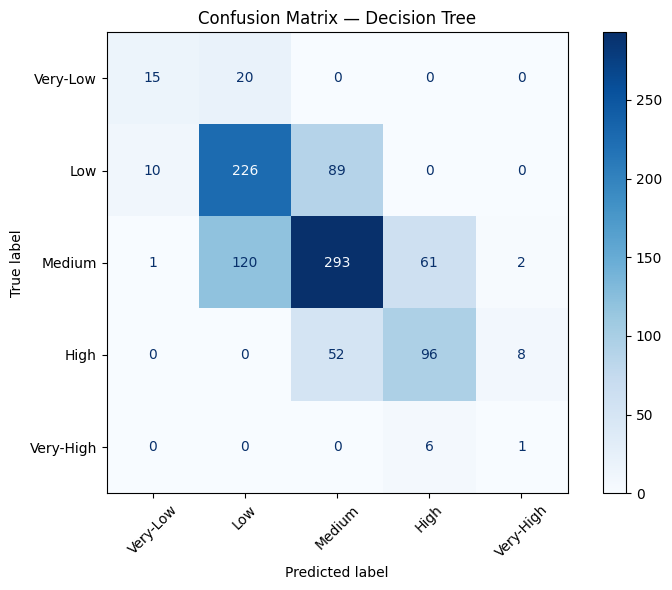


--- KNN (params: {'clf__n_neighbors': 3, 'clf__weights': 'distance'}) ---
F1-macro (gold standard) : 0.4016
Accuracy (secundária)    : 0.5470

Classification Report:
              precision    recall  f1-score   support

    Very-Low       0.41      0.34      0.37       156
         Low       0.56      0.54      0.55       325
      Medium       0.58      0.65      0.61       477
        High       0.50      0.14      0.22         7
   Very-High       0.33      0.20      0.25        35

    accuracy                           0.55      1000
   macro avg       0.48      0.37      0.40      1000
weighted avg       0.54      0.55      0.54      1000

Total de erros: 453 de 1000
Erros graves (≥2 classes de distância): 28
Classe mais confundida: Medium


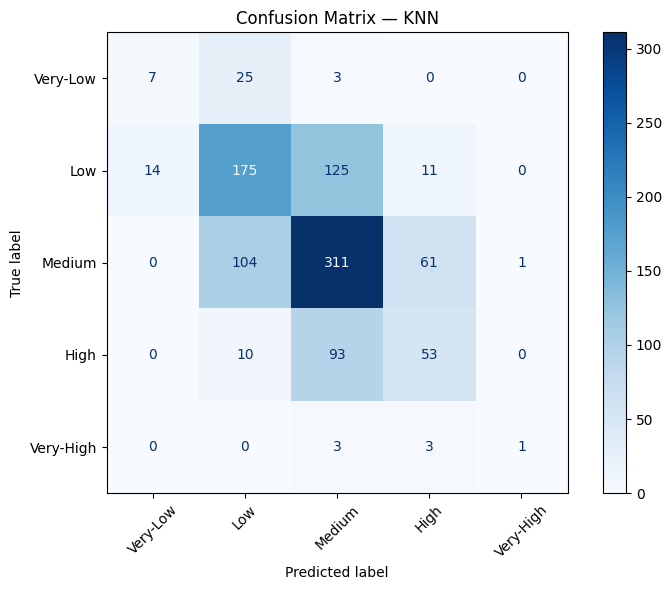

In [15]:
print("=" * 60)
print("CLASSIFICAÇÃO — Avaliação no Test Set (melhores modelos GS)")
print("=" * 60)

for name, gs in gs_clf_results.items():
    # best_estimator_ é um Pipeline (prep + clf) já re-treinado em todo X_train
    best_model = gs.best_estimator_
    y_pred = best_model.predict(X_test_clf)

    acc = accuracy_score(y_test_clf, y_pred)
    f1  = f1_score(y_test_clf, y_pred, average="macro")

    print(f"\n--- {name} (params: {gs.best_params_}) ---")
    print(f"F1-macro (gold standard) : {f1:.4f}")
    print(f"Accuracy (secundária)    : {acc:.4f}")
    print(f"\nClassification Report:")
    print(classification_report(y_test_clf, y_pred, target_names=labels, zero_division=0))

    # Análise dos erros
    errors = y_test_clf.values != y_pred
    print(f"Total de erros: {errors.sum()} de {len(y_test_clf)}")

    class_order = {"Very-Low": 0, "Low": 1, "Medium": 2, "High": 3, "Very-High": 4}
    y_real_num = pd.Series(y_test_clf.values).astype(str).map(class_order)
    y_pred_num = pd.Series(y_pred).astype(str).map(class_order)
    distancia  = (y_real_num - y_pred_num).abs()

    print(f"Erros graves (≥2 classes de distância): {(distancia >= 2).sum()}")
    print(f"Classe mais confundida: {pd.Series(y_pred[errors]).value_counts().idxmax()}")

    cm   = confusion_matrix(y_test_clf, y_pred, labels=labels)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=labels)
    fig, ax = plt.subplots(figsize=(8, 6))
    disp.plot(cmap="Blues", ax=ax)
    plt.title(f"Confusion Matrix — {name}")
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()


REGRESSÃO — Avaliação no Test Set (melhores modelos GS)

--- Linear Regression (sem grid search) ---
R²   (gold standard) : 0.6477
MAE  (secundária)    : 5.5258
RMSE                 : 6.9290

Top 5 maiores erros:
     y_real     y_pred   erro_abs
519   43.46  19.338572  24.121428
188   37.73  14.854562  22.875438
558   43.23  21.715171  21.514829
987    2.01  23.077829  21.067829
771    6.75  27.082069  20.332069


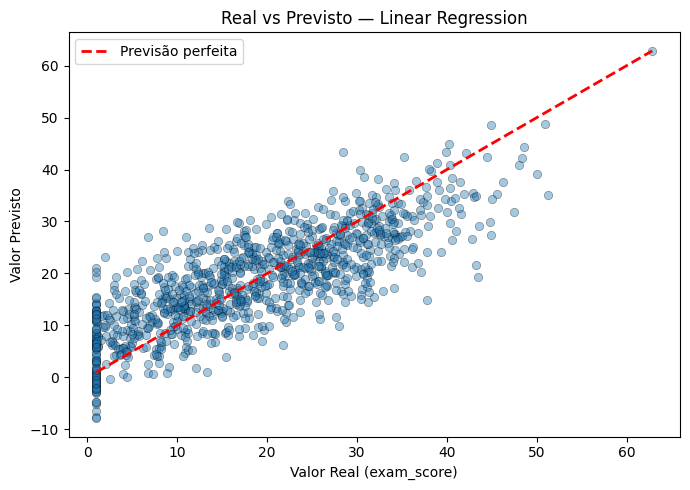


--- Decision Tree Regressor ({'reg__max_depth': 5, 'reg__min_samples_split': 2}) ---
R²   (gold standard) : 0.4647
MAE  (secundária)    : 6.8481
RMSE                 : 8.5404

Top 5 maiores erros:
     y_real     y_pred   erro_abs
423   32.86   6.724216  26.135784
188   37.73  11.694628  26.035372
499   44.89  19.820290  25.069710
863    6.07  30.929603  24.859603
558   43.23  18.650765  24.579235


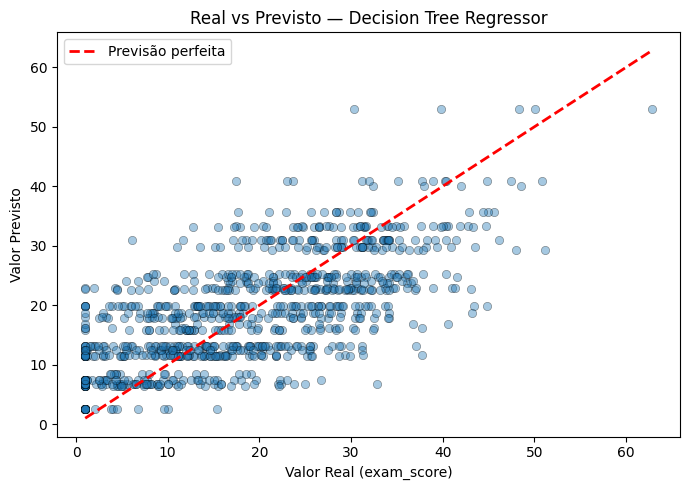

In [16]:
print("=" * 60)
print("REGRESSÃO — Avaliação no Test Set (melhores modelos GS)")
print("=" * 60)

for name, estimator in gs_reg_results.items():
    # Para LinearRegression: estimator é já a Pipeline treinada
    # Para DecisionTreeRegressor: estimator é GridSearchCV → usar best_estimator_
    if isinstance(estimator, GridSearchCV):
        best_model = estimator.best_estimator_
        params_str = str(estimator.best_params_)
    else:
        best_model = estimator
        params_str = "sem grid search"

    y_pred = best_model.predict(X_test_reg)

    r2   = r2_score(y_test_reg, y_pred)
    mae  = mean_absolute_error(y_test_reg, y_pred)
    rmse = root_mean_squared_error(y_test_reg, y_pred)

    print(f"\n--- {name} ({params_str}) ---")
    print(f"R²   (gold standard) : {r2:.4f}")
    print(f"MAE  (secundária)    : {mae:.4f}")
    print(f"RMSE                 : {rmse:.4f}")

    erros_r  = y_test_reg.values - y_pred
    erros_df = pd.DataFrame({
        "y_real":   y_test_reg.values,
        "y_pred":   y_pred,
        "erro_abs": abs(erros_r)
    })
    print(f"\nTop 5 maiores erros:")
    print(erros_df.nlargest(5, "erro_abs"))

    plt.figure(figsize=(7, 5))
    plt.scatter(y_test_reg, y_pred, alpha=0.4, edgecolors="k", linewidths=0.5)
    plt.plot([y_test_reg.min(), y_test_reg.max()],
             [y_test_reg.min(), y_test_reg.max()],
             "r--", linewidth=2, label="Previsão perfeita")
    plt.xlabel("Valor Real (exam_score)")
    plt.ylabel("Valor Previsto")
    plt.title(f"Real vs Previsto — {name}")
    plt.legend()
    plt.tight_layout()
    plt.show()


## 2.7 Análise de Erros
### Análise de Erro — Classificação

Os modelos apresentam maior dificuldade nas classes extremas (Very-Low e Very-High), possivelmente devido ao menor número de amostras. 

A classe Medium é a mais confundida, por representar a zona intermédia da variável alvo. 

A maioria dos erros ocorre entre classes adjacentes, indicando previsões próximas do valor correto. A Decision Tree apresentou menos erros graves que o KNN, sugerindo melhor separação entre classes.

### Análise de Erro — Regressão

Os modelos apresentam maiores erros na previsão de valores próximos das extremidades da variável alvo, onde existem menos observações no conjunto de dados.

Nestes casos, ambos os modelos tendem a falhar mais, o que indica dificuldades em generalizar para regiões menos representadas da distribuição.

No Decision Tree Regressor, os erros são mais instáveis e abruptos, com algumas previsões muito afastadas dos valores reais, indicando sensibilidade a variações nos dados e possível sobreajuste.

De forma geral, os erros não são aleatórios, mas estão relacionados com a distribuição dos dados, ocorrendo mais frequentemente em valores raros ou extremos.


